In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset

df = pd.read_csv("fraud_detection.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 100,000
Columns: 28


In [3]:
df.head()

,customer_id,transaction_id,customer_age,account_age_days,customer_gender,customer_income,account_balance,transaction_amount,transaction_hour,transaction_day,...,transactions_last_24h,transactions_last_7d,avg_transaction_amount,previous_transaction_amount,time_since_last_transaction_min,failed_transaction_count_24h,new_device_used,location_mismatch,unusual_transaction_time,is_fraud
0,100001,TXN0000001,39,918,Male,50105.0,70515.36,1794.21,17,Sunday,...,3,24,2832.70,1581.43,180,0,No,No,No,0
1,100002,TXN0000002,25,359,Other,62590.0,28556.52,2559.36,18,Wednesday,...,6,20,2597.48,5180.75,505,0,No,No,No,0
2,100003,TXN0000003,44,866,Other,152167.0,63270.12,814.52,6,Monday,...,7,20,621.82,630.25,674,0,No,No,No,0
3,100004,TXN0000004,46,1238,Female,101289.0,25912.31,16886.13,15,Friday,...,7,13,22140.51,9914.70,994,0,No,No,No,0
4,100005,TXN0000005,18,1508,Female,29246.0,88716.95,930.44,13,Tuesday,...,5,12,619.15,1268.59,47,0,No,Yes,No,0


In [4]:
df.tail()

,customer_id,transaction_id,customer_age,account_age_days,customer_gender,customer_income,account_balance,transaction_amount,transaction_hour,transaction_day,...,transactions_last_24h,transactions_last_7d,avg_transaction_amount,previous_transaction_amount,time_since_last_transaction_min,failed_transaction_count_24h,new_device_used,location_mismatch,unusual_transaction_time,is_fraud
99995,199996,TXN0099996,47,1086,Female,55816.0,57041.10,1268.38,19,Friday,...,2,24,937.44,4170.88,2186,0,Yes,No,No,0
99996,199997,TXN0099997,44,2060,Female,61032.0,30747.64,9596.97,11,Friday,...,3,22,4547.33,9578.51,647,0,No,No,No,0
99997,199998,TXN0099998,53,975,Female,26242.0,162840.65,5839.50,19,Thursday,...,6,23,5461.11,5021.81,180,0,No,No,No,0
99998,199999,TXN0099999,34,188,Male,53139.0,19051.43,1404.85,5,Friday,...,3,20,958.68,1073.57,99,0,No,No,Yes,0
99999,200000,TXN0100000,43,1955,Male,55355.0,83972.46,644.77,16,Thursday,...,4,17,740.62,1039.14,349,0,Yes,No,No,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   customer_id                      100000 non-null  int64  
 1   transaction_id                   100000 non-null  object 
 2   customer_age                     100000 non-null  int64  
 3   account_age_days                 100000 non-null  int64  
 4   customer_gender                  100000 non-null  object 
 5   customer_income                  99700 non-null   float64
 6   account_balance                  100000 non-null  float64
 7   transaction_amount               100000 non-null  float64
 8   transaction_hour                 100000 non-null  int64  
 9   transaction_day                  100000 non-null  object 
 10  transaction_type                 100000 non-null  object 
 11  merchant_category                100000 non-null  object 
 12  pay

In [6]:
df.shape

(100000, 28)

In [7]:
df.isna().sum()

customer_id                          0
transaction_id                       0
customer_age                         0
account_age_days                     0
customer_gender                      0
customer_income                    300
account_balance                      0
transaction_amount                   0
transaction_hour                     0
transaction_day                      0
transaction_type                     0
merchant_category                    0
payment_method                       0
transaction_location                 0
is_international_transaction         0
device_type                          0
device_trust_score                 200
distance_from_home_km              200
transactions_last_24h                0
transactions_last_7d                 0
avg_transaction_amount               0
previous_transaction_amount          0
time_since_last_transaction_min      0
failed_transaction_count_24h         0
new_device_used                      0
location_mismatch        

In [8]:
# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

customer_income          0.3
device_trust_score       0.2
distance_from_home_km    0.2
dtype: float64

In [9]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [10]:
# Statistical summary of numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,100000.0,150000.500000,28867.657797,100001.00,125000.7500,150000.50,175000.250,200000.00
customer_age,100000.0,36.193610,10.545163,18.00,29.0000,36.00,43.000,75.00
account_age_days,100000.0,1343.226380,747.730011,30.00,792.0000,1208.00,1751.000,5000.00
customer_income,99700.0,61727.754694,31312.821769,18000.00,39846.7500,55033.00,75958.250,300000.00
account_balance,100000.0,59983.088144,60769.862484,907.24,23628.2725,41806.87,74449.065,800000.00
transaction_amount,100000.0,3111.887777,4354.117375,50.00,884.6675,1798.29,3648.530,110106.32
transaction_hour,100000.0,14.131660,5.206407,0.00,10.0000,15.00,18.000,23.00
device_trust_score,99800.0,77.784929,13.115642,20.00,69.7000,79.90,87.900,99.90
distance_from_home_km,99800.0,24.096065,17.084895,0.10,11.5000,20.30,32.500,172.00
transactions_last_24h,100000.0,4.003940,1.730744,1.00,3.0000,4.00,5.000,14.00


In [11]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

Categorical columns:

transaction_id:
['TXN0000001' 'TXN0000002' 'TXN0000003' ... 'TXN0099998' 'TXN0099999'
 'TXN0100000']

customer_gender:
['Male' 'Other' 'Female']

transaction_day:
['Sunday' 'Wednesday' 'Monday' 'Friday' 'Tuesday' 'Thursday' 'Saturday']

transaction_type:
['Purchase' 'Bill Payment' 'ATM Withdrawal' 'Online Purchase' 'Transfer']

merchant_category:
['Electronics' 'Online Services' 'Dining' 'Clothing' 'Fuel'
 'Entertainment' 'Grocery' 'Healthcare' 'Travel']

payment_method:
['Credit Card' 'Debit Card' 'Online' 'Contactless']

transaction_location:
['Other' 'Chennai' 'Jaipur' 'Kolkata' 'Bengaluru' 'Delhi' 'Mumbai'
 'Hyderabad' 'Ahmedabad' 'Pune']

is_international_transaction:
['No' 'Yes']

device_type:
['Tablet' 'Mobile' 'Desktop' 'POS']

new_device_used:
['No' 'Yes']

location_mismatch:
['No' 'Yes']

unusual_transaction_time:
['No' 'Yes']


In [12]:
# Check frequency distribution of categorical features

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{column}")
    print(f"{'='*50}")
    print(df[column].value_counts())


transaction_id
transaction_id
TXN0099961    1
TXN0099962    1
TXN0099963    1
TXN0099964    1
TXN0099965    1
             ..
TXN0000004    1
TXN0000005    1
TXN0000006    1
TXN0000007    1
TXN0000008    1
Name: count, Length: 100000, dtype: int64

customer_gender
customer_gender
Male      49253
Female    48702
Other      2045
Name: count, dtype: int64

transaction_day
transaction_day
Friday       16057
Tuesday      14569
Monday       14491
Thursday     14437
Wednesday    14211
Sunday       13126
Saturday     13109
Name: count, dtype: int64

transaction_type
transaction_type
Purchase           38879
Online Purchase    27085
Bill Payment       12119
Transfer           11882
ATM Withdrawal     10035
Name: count, dtype: int64

merchant_category
merchant_category
Grocery            17949
Dining             13037
Clothing           12075
Online Services    12068
Electronics        11046
Fuel                9896
Entertainment       7981
Travel              7976
Healthcare          7972
Name

In [13]:
# Check target variable distribution

fraud_counts = df["is_fraud"].value_counts()
fraud_percentage = df["is_fraud"].value_counts(normalize=True) * 100

print("Transaction Count:")
print(fraud_counts)

print("\nTransaction Percentage:")
print(fraud_percentage)

Transaction Count:
is_fraud
0    98000
1     2000
Name: count, dtype: int64

Transaction Percentage:
is_fraud
0    98.0
1     2.0
Name: proportion, dtype: float64


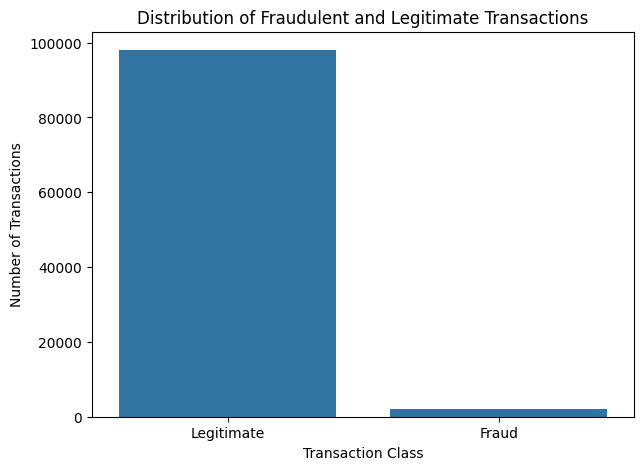

In [14]:
# Visualize target variable distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="is_fraud")

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

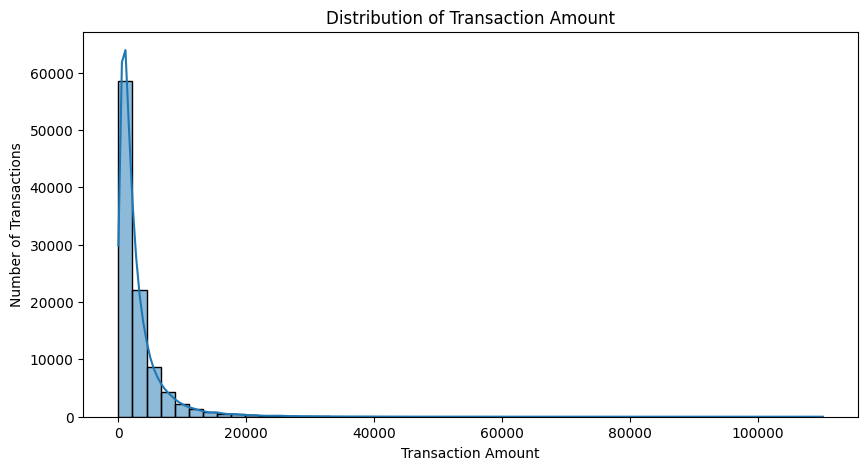

In [15]:
# Distribution of transaction amount

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="transaction_amount",
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

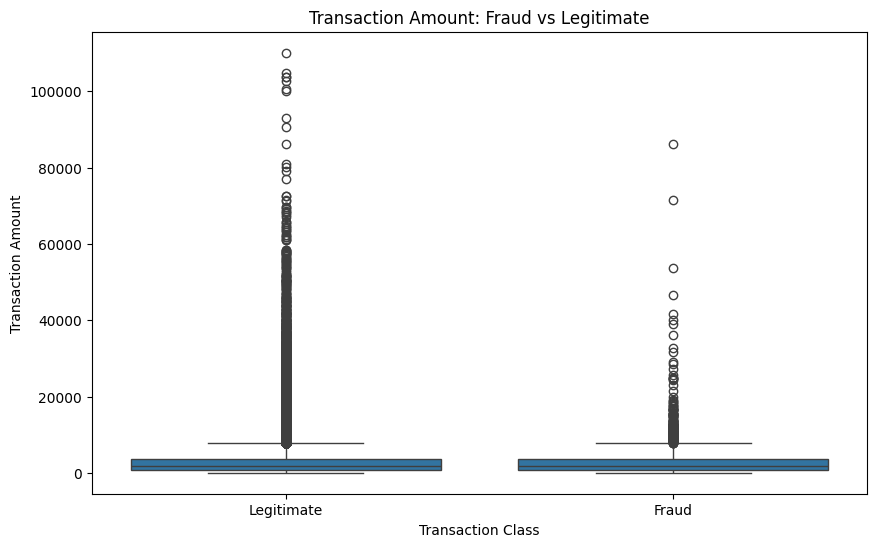

In [16]:
# Compare transaction amounts by fraud status

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="transaction_amount"
)

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

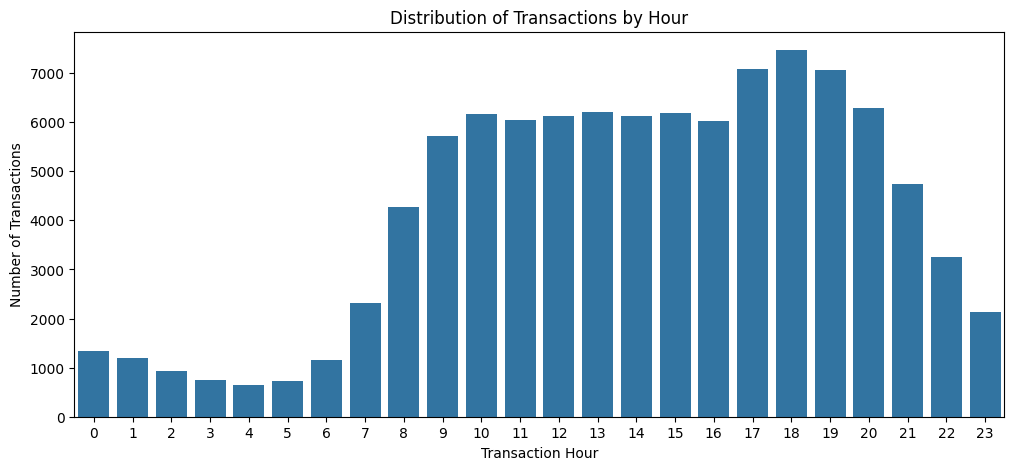

In [17]:
# Distribution of transactions by hour

plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="transaction_hour"
)

plt.title("Distribution of Transactions by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Transactions")

plt.show()

In [18]:
# Calculate fraud rate for each transaction hour

fraud_rate_by_hour = (
    df.groupby("transaction_hour")["is_fraud"]
      .mean()
      .mul(100)
)

fraud_rate_by_hour

transaction_hour
0     5.576208
1     5.294118
2     5.561497
3     6.781915
4     7.186544
5     6.934813
6     2.528335
7     1.339672
8     1.332710
9     1.680967
10    1.766040
11    1.668594
12    1.695468
13    1.721641
14    1.891099
15    1.536720
16    1.675236
17    1.653710
18    1.633637
19    1.868894
20    1.735116
21    1.958307
22    1.686599
23    4.117922
Name: is_fraud, dtype: float64

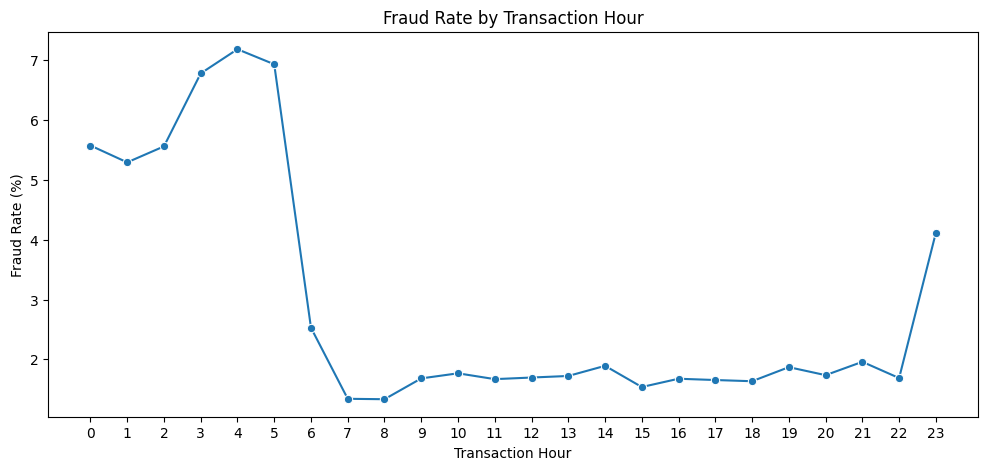

In [19]:
# Visualize fraud rate by transaction hour

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=fraud_rate_by_hour.index,
    y=fraud_rate_by_hour.values,
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

In [20]:
# Calculate fraud rate by transaction type

fraud_rate_by_type = (
    df.groupby("transaction_type")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_type

transaction_type
Online Purchase    2.890899
Purchase           1.718151
Bill Payment       1.642050
ATM Withdrawal     1.634280
Transfer           1.565393
Name: is_fraud, dtype: float64

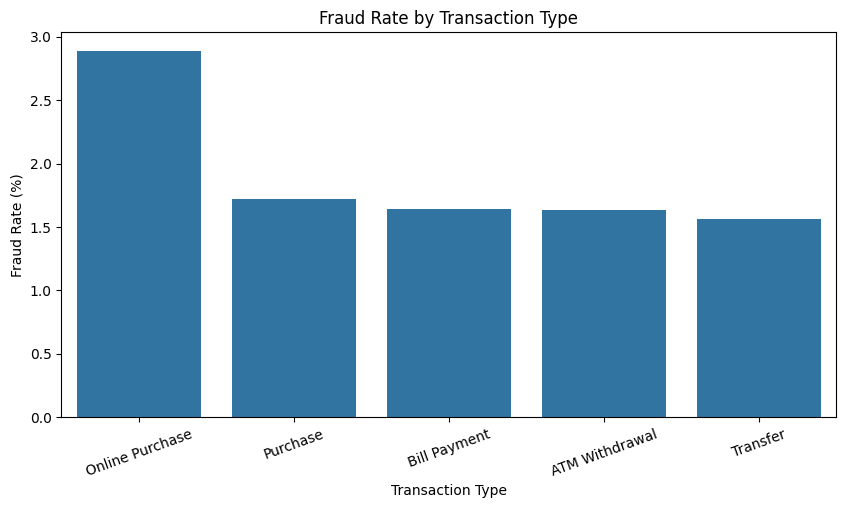

In [21]:
# Visualize fraud rate by transaction type

plt.figure(figsize=(10, 5))

sns.barplot(
    x=fraud_rate_by_type.index,
    y=fraud_rate_by_type.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [22]:
# Calculate fraud rate by merchant category

fraud_rate_by_merchant = (
    df.groupby("merchant_category")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_merchant

merchant_category
Clothing           2.103520
Dining             2.101711
Grocery            2.100396
Electronics        2.036936
Travel             1.968405
Fuel               1.919968
Entertainment      1.904523
Online Services    1.897580
Healthcare         1.781234
Name: is_fraud, dtype: float64

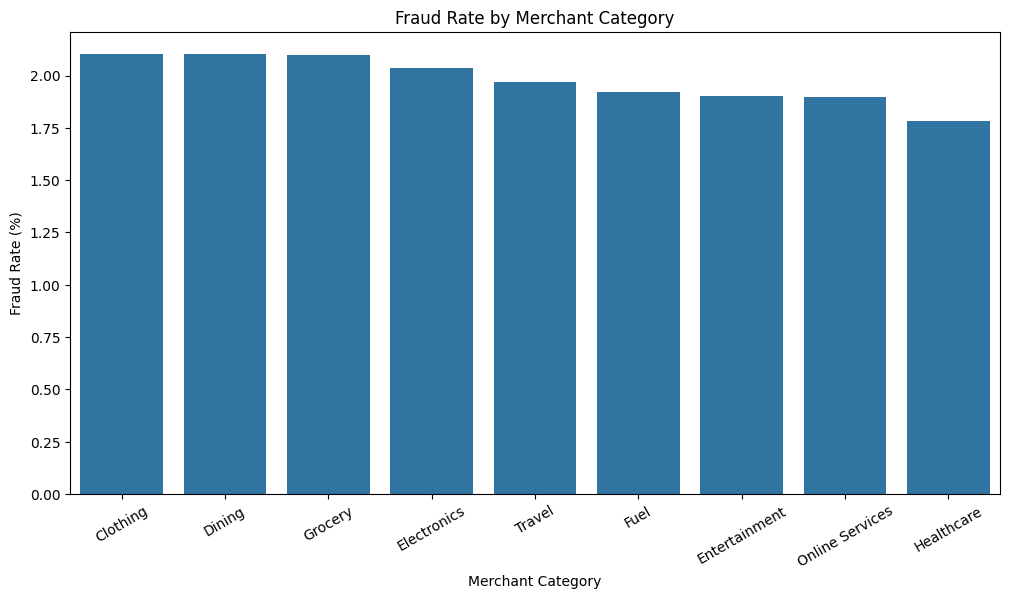

In [23]:
# Visualize fraud rate by merchant category

plt.figure(figsize=(12, 6))

sns.barplot(
    x=fraud_rate_by_merchant.index,
    y=fraud_rate_by_merchant.values
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [24]:
# Calculate fraud rate by payment method

fraud_rate_by_payment = (
    df.groupby("payment_method")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_payment

payment_method
Online         3.600402
Contactless    1.825702
Debit Card     1.698778
Credit Card    1.689080
Name: is_fraud, dtype: float64

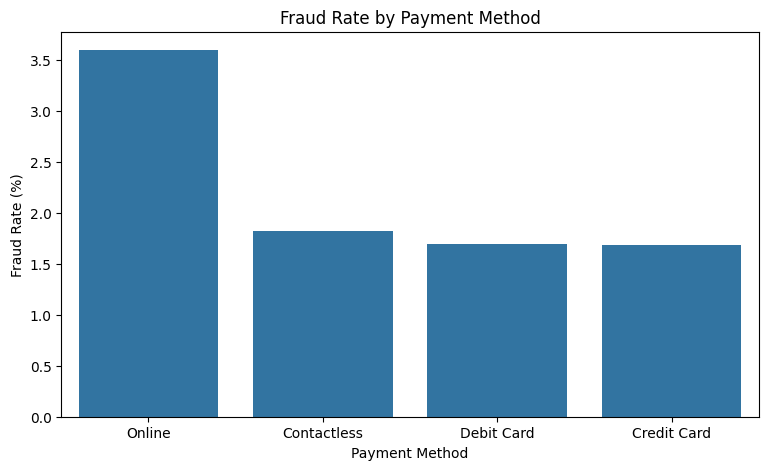

In [25]:
# Visualize fraud rate by payment method

plt.figure(figsize=(9, 5))

sns.barplot(
    x=fraud_rate_by_payment.index,
    y=fraud_rate_by_payment.values
)

plt.title("Fraud Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [26]:
# Calculate fraud rate by device type

fraud_rate_by_device = (
    df.groupby("device_type")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_device

device_type
Tablet     2.157252
Mobile     2.010361
POS        1.975781
Desktop    1.935724
Name: is_fraud, dtype: float64

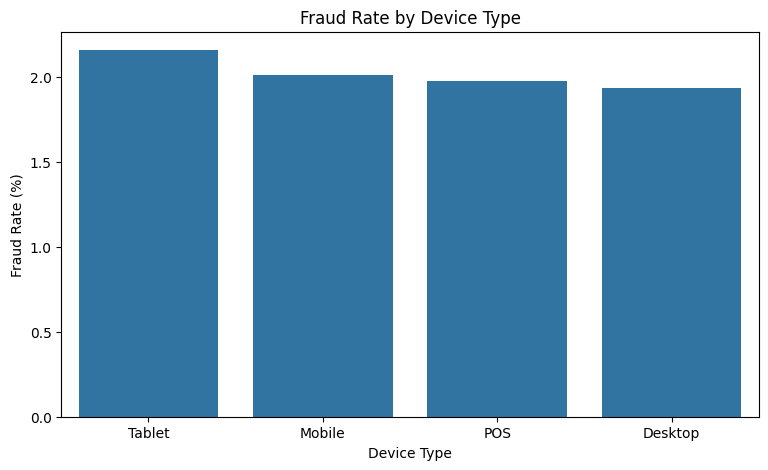

In [27]:
# Visualize fraud rate by device type

plt.figure(figsize=(9, 5))

sns.barplot(
    x=fraud_rate_by_device.index,
    y=fraud_rate_by_device.values
)

plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [28]:
# Calculate fraud rate by international transaction status

fraud_rate_by_international = (
    df.groupby("is_international_transaction")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_international

is_international_transaction
Yes    7.448047
No     1.651327
Name: is_fraud, dtype: float64

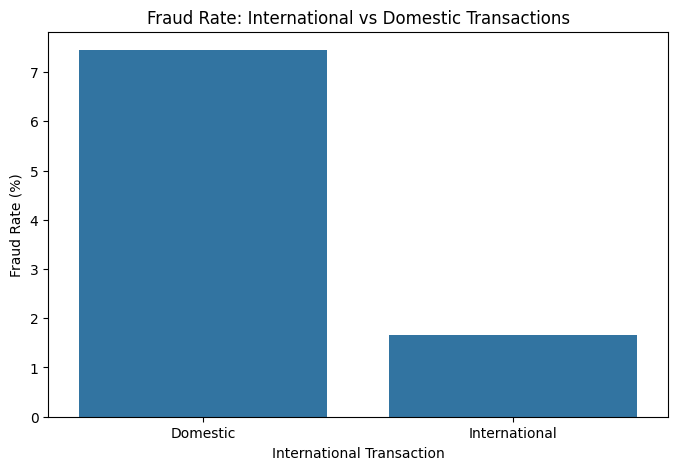

In [29]:
# Visualize fraud rate by international transaction status

plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_rate_by_international.index,
    y=fraud_rate_by_international.values
)

plt.title("Fraud Rate: International vs Domestic Transactions")
plt.xlabel("International Transaction")
plt.ylabel("Fraud Rate (%)")
plt.xticks([0, 1], ["Domestic", "International"])

plt.show()

In [30]:
# Calculate fraud rate by customer gender

fraud_rate_by_gender = (
    df.groupby("customer_gender")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_by_gender

customer_gender
Other     2.102689
Female    2.008131
Male      1.987696
Name: is_fraud, dtype: float64

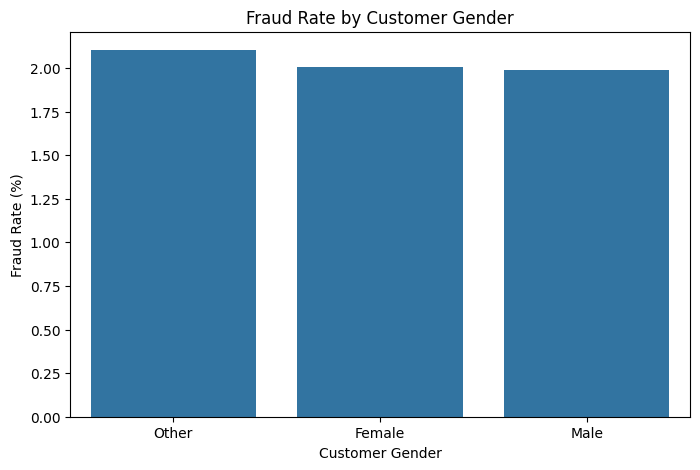

In [31]:
# Visualize fraud rate by customer gender

plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_rate_by_gender.index,
    y=fraud_rate_by_gender.values
)

plt.title("Fraud Rate by Customer Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Fraud Rate (%)")

plt.show()

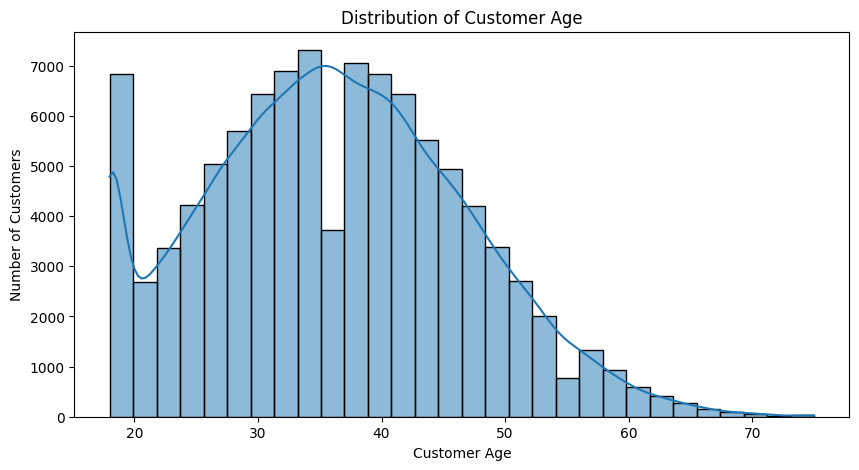

In [32]:
# Distribution of customer age

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="customer_age",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")

plt.show()

In [33]:
# Create age groups

age_bins = [18, 25, 35, 45, 55, 65, 75]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-75"]

df["age_group"] = pd.cut(
    df["customer_age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# Calculate fraud rate by age group

fraud_rate_by_age = (
    df.groupby("age_group", observed=True)["is_fraud"]
      .mean()
      .mul(100)
)

fraud_rate_by_age

age_group
18-24    1.934834
25-34    2.113620
35-44    2.025385
45-54    1.855610
55-64    1.884992
65-75    1.273885
Name: is_fraud, dtype: float64

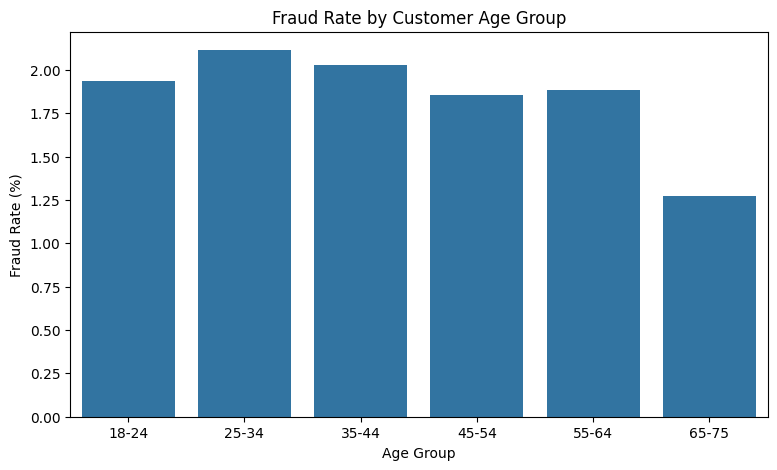

In [34]:
# Visualize fraud rate by age group

plt.figure(figsize=(9, 5))

sns.barplot(
    x=fraud_rate_by_age.index,
    y=fraud_rate_by_age.values
)

plt.title("Fraud Rate by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate (%)")

plt.show()

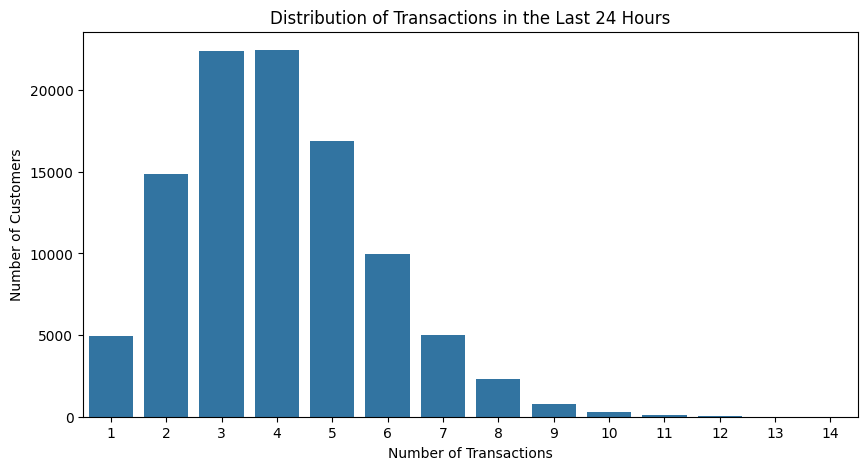

In [35]:
# Distribution of transactions in the last 24 hours

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="transactions_last_24h"
)

plt.title("Distribution of Transactions in the Last 24 Hours")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.show()

In [36]:
# Calculate fraud rate by number of transactions in the last 24 hours

fraud_rate_by_tx_24h = (
    df.groupby("transactions_last_24h")["is_fraud"]
      .mean()
      .mul(100)
)

fraud_rate_by_tx_24h

transactions_last_24h
1      2.209161
2      1.874244
3      1.939838
4      1.883516
5      1.815386
6      2.235589
7      2.575364
8      2.465398
9      2.435897
10     5.769231
11     2.597403
12    14.285714
13     0.000000
14     0.000000
Name: is_fraud, dtype: float64

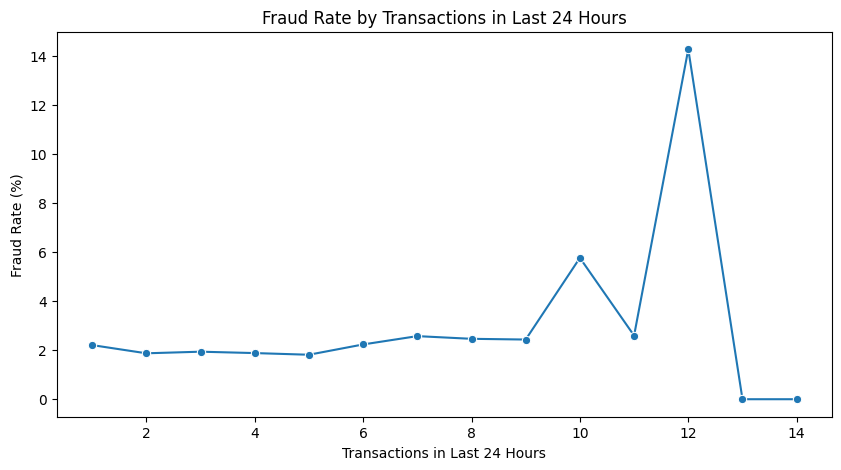

In [37]:
# Visualize fraud rate by transaction frequency

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=fraud_rate_by_tx_24h.index,
    y=fraud_rate_by_tx_24h.values,
    marker="o"
)

plt.title("Fraud Rate by Transactions in Last 24 Hours")
plt.xlabel("Transactions in Last 24 Hours")
plt.ylabel("Fraud Rate (%)")

plt.show()

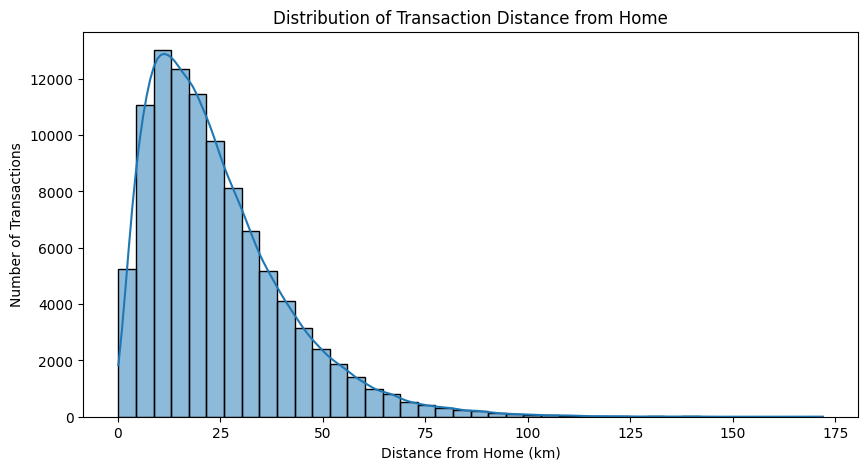

In [38]:
# Distribution of distance from home

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="distance_from_home_km",
    bins=40,
    kde=True
)

plt.title("Distribution of Transaction Distance from Home")
plt.xlabel("Distance from Home (km)")
plt.ylabel("Number of Transactions")

plt.show()

In [39]:
# Create distance groups

distance_bins = [0, 5, 10, 25, 50, 100, 500]
distance_labels = ["0-5 km", "5-10 km", "10-25 km", "25-50 km", "50-100 km", "100+ km"]

df["distance_group"] = pd.cut(
    df["distance_from_home_km"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

# Calculate fraud rate by distance group

fraud_rate_by_distance = (
    df.groupby("distance_group", observed=True)["is_fraud"]
      .mean()
      .mul(100)
)

fraud_rate_by_distance

distance_group
0-5 km        1.382353
5-10 km       1.636021
10-25 km      1.599273
25-50 km      1.483211
50-100 km     5.280612
100+ km      69.527897
Name: is_fraud, dtype: float64

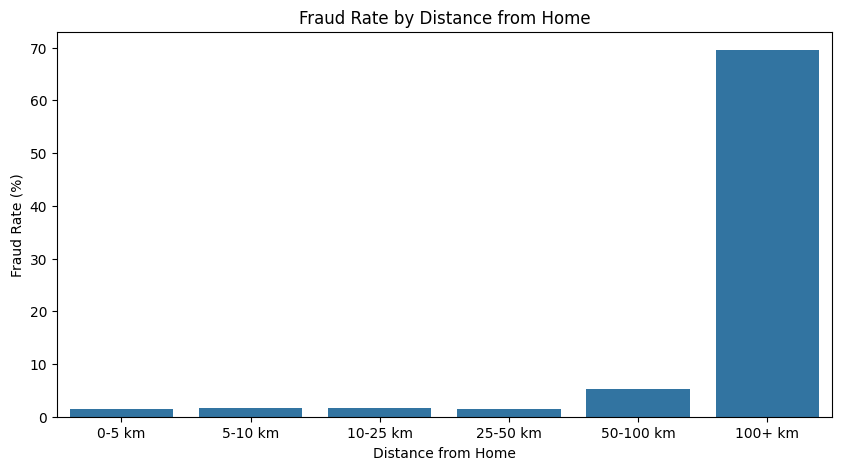

In [40]:
# Visualize fraud rate by distance from home

plt.figure(figsize=(10, 5))

sns.barplot(
    x=fraud_rate_by_distance.index,
    y=fraud_rate_by_distance.values
)

plt.title("Fraud Rate by Distance from Home")
plt.xlabel("Distance from Home")
plt.ylabel("Fraud Rate (%)")

plt.show()

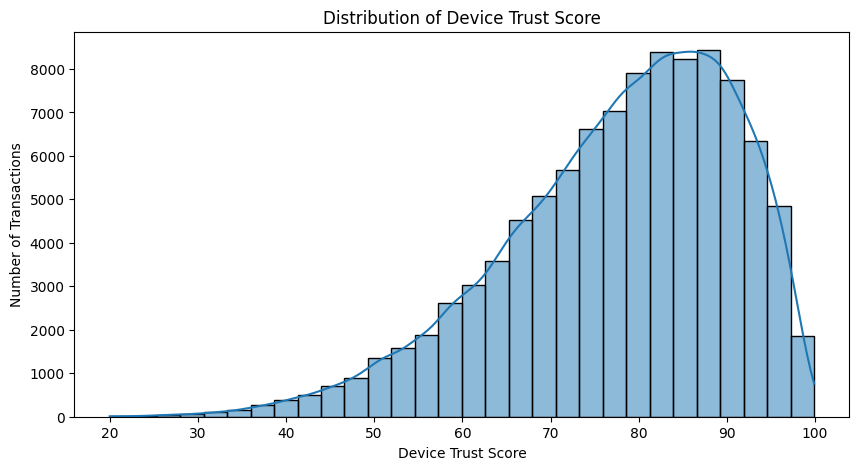

In [41]:
# Distribution of device trust score

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="device_trust_score",
    bins=30,
    kde=True
)

plt.title("Distribution of Device Trust Score")
plt.xlabel("Device Trust Score")
plt.ylabel("Number of Transactions")

plt.show()

In [42]:
# Correlation of numerical features with the target variable

numeric_columns = df.select_dtypes(include=np.number).columns

correlation_with_fraud = (
    df[numeric_columns]
    .corr()["is_fraud"]
    .sort_values(ascending=False)
)

correlation_with_fraud

is_fraud                           1.000000
distance_from_home_km              0.135982
failed_transaction_count_24h       0.026688
transactions_last_24h              0.010900
transaction_amount                 0.002330
avg_transaction_amount             0.002325
previous_transaction_amount        0.001649
time_since_last_transaction_min    0.000596
customer_id                       -0.001169
account_balance                   -0.001727
customer_age                      -0.002792
account_age_days                  -0.003538
transactions_last_7d              -0.003922
customer_income                   -0.004737
transaction_hour                  -0.030585
device_trust_score                -0.054658
Name: is_fraud, dtype: float64

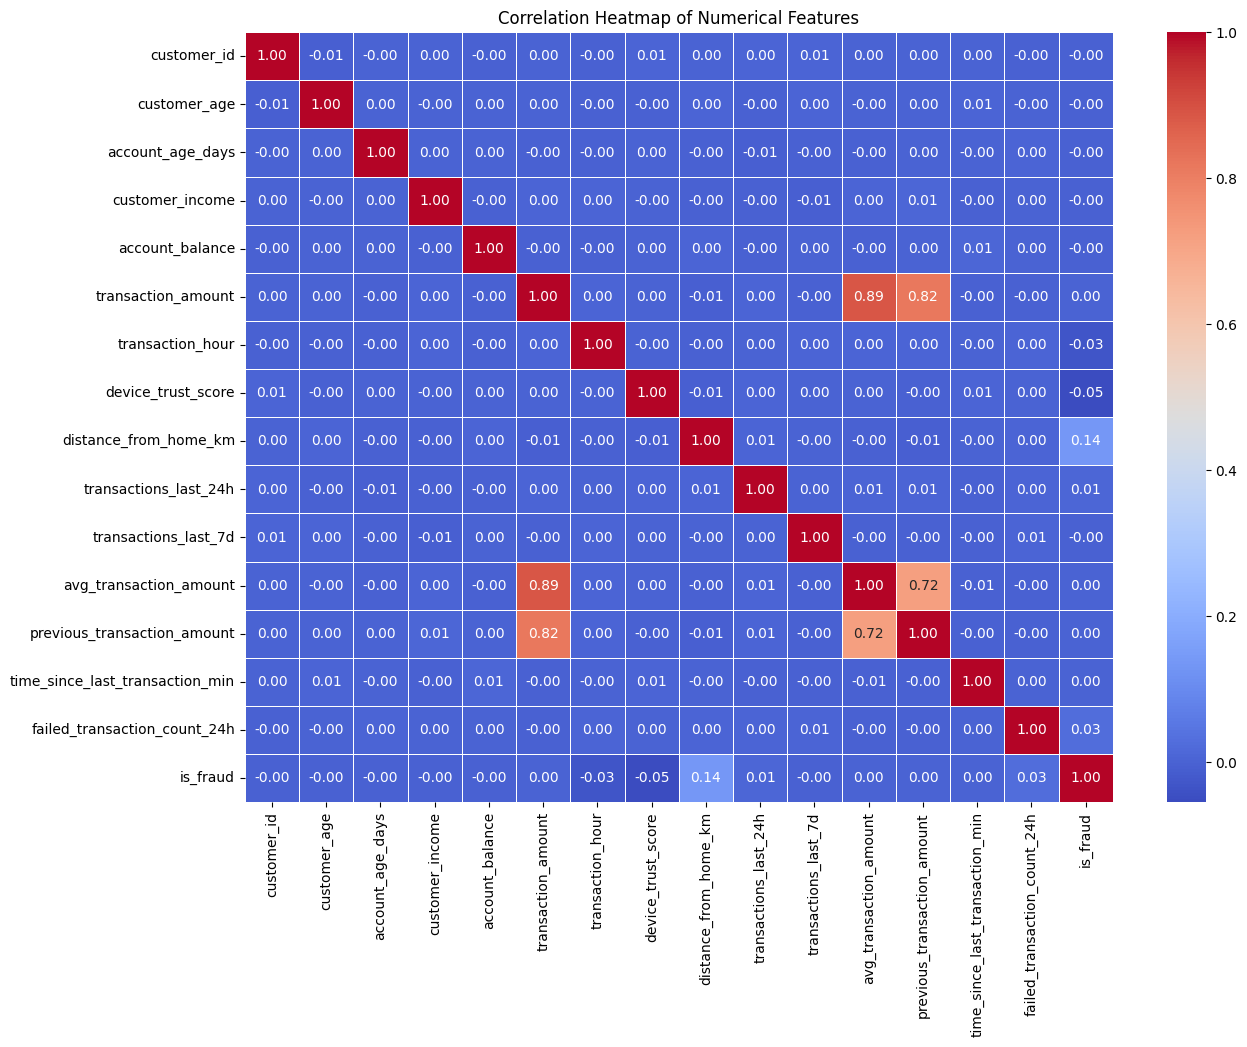

In [43]:
# Correlation heatmap for numerical features

plt.figure(figsize=(14, 10))

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

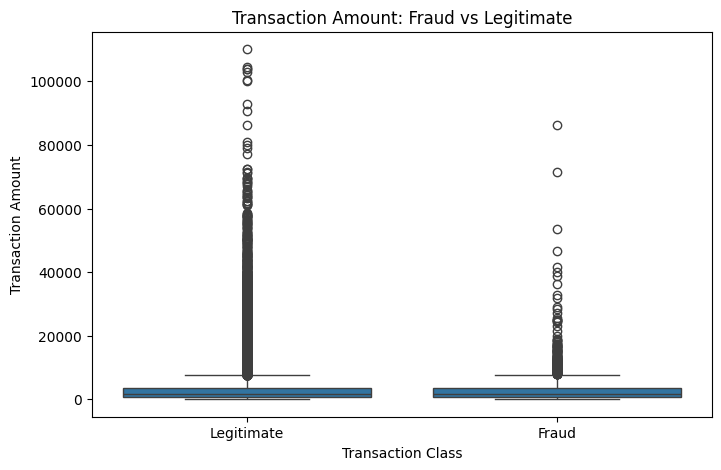

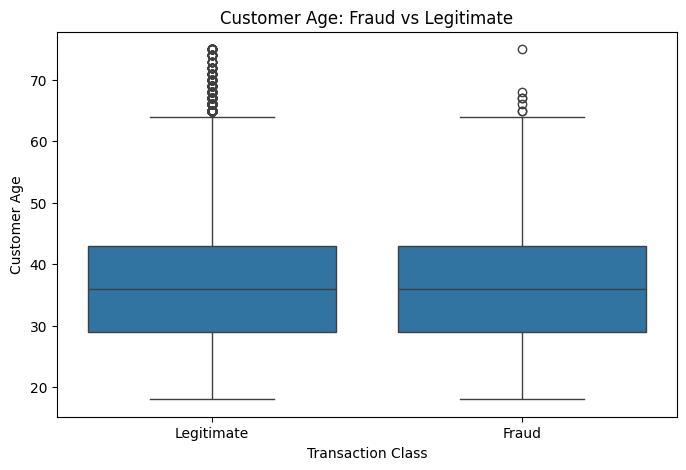

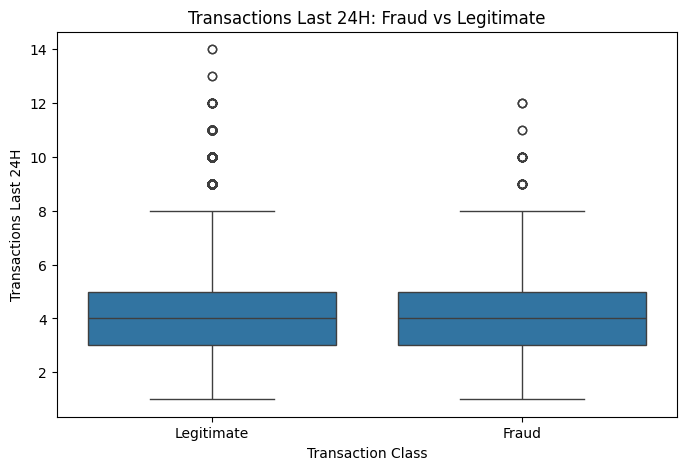

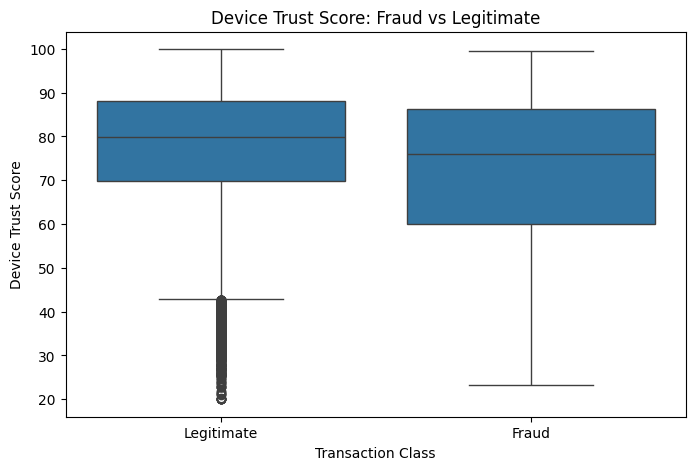

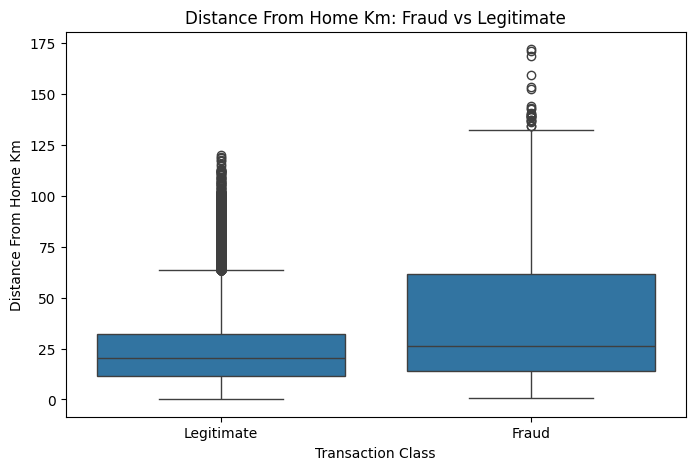

In [44]:
# Compare important numerical features by fraud status

features_to_compare = [
    "transaction_amount",
    "customer_age",
    "transactions_last_24h",
    "device_trust_score",
    "distance_from_home_km"
]

for feature in features_to_compare:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="is_fraud",
        y=feature
    )
    
    plt.title(f"{feature.replace('_', ' ').title()}: Fraud vs Legitimate")
    plt.xlabel("Transaction Class")
    plt.ylabel(feature.replace("_", " ").title())
    plt.xticks([0, 1], ["Legitimate", "Fraud"])
    
    plt.show()

In [45]:
# Check outliers using the IQR method

outlier_features = [
    "transaction_amount",
    "transactions_last_24h",
    "distance_from_home_km"
]

for feature in outlier_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    print(f"{feature}:")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Number of Outliers: {len(outliers):,}")
    print()

transaction_amount:
  Lower Bound: -3261.13
  Upper Bound: 7794.32
  Number of Outliers: 8,136

transactions_last_24h:
  Lower Bound: 0.00
  Upper Bound: 8.00
  Number of Outliers: 1,142

distance_from_home_km:
  Lower Bound: -20.00
  Upper Bound: 64.00
  Number of Outliers: 3,098



In [46]:
# EDA Summary

print("========== EDA SUMMARY ==========\n")

print("1. Dataset Shape:")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}\n")

print("2. Missing Values:")
print(f"   Total missing values: {df.isnull().sum().sum():,}\n")

print("3. Duplicate Records:")
print(f"   Total duplicates: {df.duplicated().sum():,}\n")

print("4. Target Distribution:")
print(df["is_fraud"].value_counts())
print()

print("5. Target Percentage:")
print((df["is_fraud"].value_counts(normalize=True) * 100).round(2))
print()

print("6. Numerical Features:")
print(f"   {len(numeric_columns)} numerical features\n")

print("7. Categorical Features:")
print(f"   {len(categorical_columns)} categorical features")

========== EDA SUMMARY ==========

1. Dataset Shape:
   Rows    : 100,000
   Columns : 30

2. Missing Values:
   Total missing values: 927

3. Duplicate Records:
   Total duplicates: 0

4. Target Distribution:
is_fraud
0    98000
1     2000
Name: count, dtype: int64

5. Target Percentage:
is_fraud
0    98.0
1     2.0
Name: proportion, dtype: float64

6. Numerical Features:
   16 numerical features

7. Categorical Features:
   12 categorical features


In [47]:
# Display all dataset columns

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. customer_id
2. transaction_id
3. customer_age
4. account_age_days
5. customer_gender
6. customer_income
7. account_balance
8. transaction_amount
9. transaction_hour
10. transaction_day
11. transaction_type
12. merchant_category
13. payment_method
14. transaction_location
15. is_international_transaction
16. device_type
17. device_trust_score
18. distance_from_home_km
19. transactions_last_24h
20. transactions_last_7d
21. avg_transaction_amount
22. previous_transaction_amount
23. time_since_last_transaction_min
24. failed_transaction_count_24h
25. new_device_used
26. location_mismatch
27. unusual_transaction_time
28. is_fraud
29. age_group
30. distance_group


In [48]:
# Check data type and number of unique values for every column

column_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

column_summary

,Data Type,Unique Values,Missing Values
customer_id,int64,100000,0
transaction_id,object,100000,0
customer_age,int64,58,0
account_age_days,int64,4208,0
customer_gender,object,3,0
customer_income,float64,60756,300
account_balance,float64,99525,0
transaction_amount,float64,90902,0
transaction_hour,int64,24,0
transaction_day,object,7,0


In [49]:
# Remove identifier and temporary EDA columns

columns_to_drop = [
    "customer_id",
    "transaction_id",
    "age_group",
    "distance_group"
]

df = df.drop(columns=columns_to_drop)

print("Dropped columns:")
for column in columns_to_drop:
    print("-", column)

print("\nRemaining columns:", df.shape[1])

Dropped columns:
- customer_id
- transaction_id
- age_group
- distance_group

Remaining columns: 26


In [50]:
# Separate features and target variable

X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100000, 25)
Target shape: (100000,)


In [51]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (80000, 25)
Testing features : (20000, 25)
Training target  : (80000,)
Testing target   : (20000,)


In [52]:
# Check fraud distribution in training and testing sets

print("Training Set:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Set:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Set:
is_fraud
0    78400
1     1600
Name: count, dtype: int64
is_fraud
0    98.0
1     2.0
Name: proportion, dtype: float64

Testing Set:
is_fraud
0    19600
1      400
Name: count, dtype: int64
is_fraud
0    98.0
1     2.0
Name: proportion, dtype: float64


In [53]:
# Identify numerical and categorical features

numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['customer_age', 'account_age_days', 'customer_income', 'account_balance', 'transaction_amount', 'transaction_hour', 'device_trust_score', 'distance_from_home_km', 'transactions_last_24h', 'transactions_last_7d', 'avg_transaction_amount', 'previous_transaction_amount', 'time_since_last_transaction_min', 'failed_transaction_count_24h']

Categorical features:
['customer_gender', 'transaction_day', 'transaction_type', 'merchant_category', 'payment_method', 'transaction_location', 'is_international_transaction', 'device_type', 'new_device_used', 'location_mismatch', 'unusual_transaction_time']


In [54]:
# Import preprocessing tools

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [55]:
# Apply preprocessing to training and testing data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")
print("Training data shape:", X_train_processed.shape)
print("Testing data shape :", X_test_processed.shape)

Preprocessing completed successfully!
Training data shape: (80000, 64)
Testing data shape : (20000, 64)


In [56]:
# Verify that preprocessing has removed missing values

import scipy.sparse as sp

if sp.issparse(X_train_processed):
    missing_train = np.isnan(X_train_processed.data).sum()
    missing_test = np.isnan(X_test_processed.data).sum()
else:
    missing_train = np.isnan(X_train_processed).sum()
    missing_test = np.isnan(X_test_processed).sum()

print("Missing values after preprocessing:")
print("Training data:", missing_train)
print("Testing data :", missing_test)

Missing values after preprocessing:
Training data: 0
Testing data : 0


In [57]:
# Get feature names after preprocessing

processed_feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(processed_feature_names))
print("\nFirst 20 processed features:")
print(processed_feature_names[:20])

Total processed features: 64

First 20 processed features:
['num__customer_age' 'num__account_age_days' 'num__customer_income'
 'num__account_balance' 'num__transaction_amount' 'num__transaction_hour'
 'num__device_trust_score' 'num__distance_from_home_km'
 'num__transactions_last_24h' 'num__transactions_last_7d'
 'num__avg_transaction_amount' 'num__previous_transaction_amount'
 'num__time_since_last_transaction_min'
 'num__failed_transaction_count_24h' 'cat__customer_gender_Female'
 'cat__customer_gender_Male' 'cat__customer_gender_Other'
 'cat__transaction_day_Friday' 'cat__transaction_day_Monday'
 'cat__transaction_day_Saturday']


In [58]:
# Check class distribution before balancing

print("Class distribution before balancing:\n")

class_distribution = y_train.value_counts()

print(class_distribution)

print("\nClass percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Class distribution before balancing:

is_fraud
0    78400
1     1600
Name: count, dtype: int64

Class percentage:
is_fraud
0    98.0
1     2.0
Name: proportion, dtype: float64


In [61]:
# Balance the training data using SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Class distribution after SMOTE:\n")
print(y_train_balanced.value_counts())

print("\nClass percentage after SMOTE:")
print(
    (y_train_balanced.value_counts(normalize=True) * 100)
    .round(2)
)

  File "C:\Users\shripad pawar\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\shripad pawar\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shripad pawar\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process

Class distribution after SMOTE:

is_fraud
0    78400
1    78400
Name: count, dtype: int64

Class percentage after SMOTE:
is_fraud
0    50.0
1    50.0
Name: proportion, dtype: float64


In [60]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
# Final check of training and testing data

print("Training data after SMOTE:")
print("X_train_balanced shape:", X_train_balanced.shape)
print("y_train_balanced shape:", y_train_balanced.shape)

print("\nTesting data:")
print("X_test_processed shape:", X_test_processed.shape)
print("y_test shape:", y_test.shape)

print("\nData type:")
print("X_train_balanced:", type(X_train_balanced))
print("X_test_processed:", type(X_test_processed))

Training data after SMOTE:
X_train_balanced shape: (156800, 64)
y_train_balanced shape: (156800,)

Testing data:
X_test_processed shape: (20000, 64)
y_test shape: (20000,)

Data type:
X_train_balanced: <class 'numpy.ndarray'>
X_test_processed: <class 'numpy.ndarray'>


In [63]:
# Train Logistic Regression baseline model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [65]:
# Evaluate Logistic Regression

from sklearn.metrics import classification_report

y_pred_lr = logistic_model.predict(X_test_processed)

print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Legitimate", "Fraud"]
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      0.85      0.92     19600
       Fraud       0.09      0.74      0.16       400

    accuracy                           0.85     20000
   macro avg       0.54      0.79      0.54     20000
weighted avg       0.98      0.85      0.90     20000



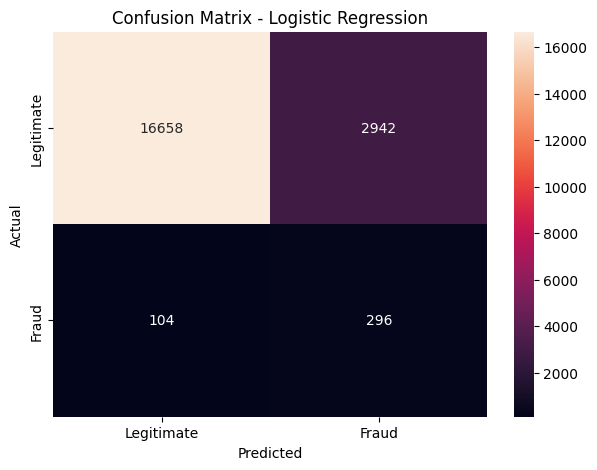

In [66]:
# Confusion Matrix for Logistic Regression

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [67]:
# Calculate ROC-AUC and PR-AUC for Logistic Regression

from sklearn.metrics import roc_auc_score, average_precision_score

# Fraud probability
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

print(f"ROC-AUC Score: {roc_auc_lr:.4f}")
print(f"PR-AUC Score : {pr_auc_lr:.4f}")

ROC-AUC Score: 0.8625
PR-AUC Score : 0.4749


In [68]:
# Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [69]:
# Make predictions using Random Forest

y_pred_rf = random_forest_model.predict(X_test_processed)

print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Legitimate", "Fraud"]
    )
)


Random Forest Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99     19600
       Fraud       0.81      0.34      0.48       400

    accuracy                           0.99     20000
   macro avg       0.90      0.67      0.73     20000
weighted avg       0.98      0.99      0.98     20000



In [70]:
# Calculate ROC-AUC and PR-AUC for Random Forest

y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print(f"ROC-AUC Score: {roc_auc_rf:.4f}")
print(f"PR-AUC Score : {pr_auc_rf:.4f}")

ROC-AUC Score: 0.8449
PR-AUC Score : 0.5470


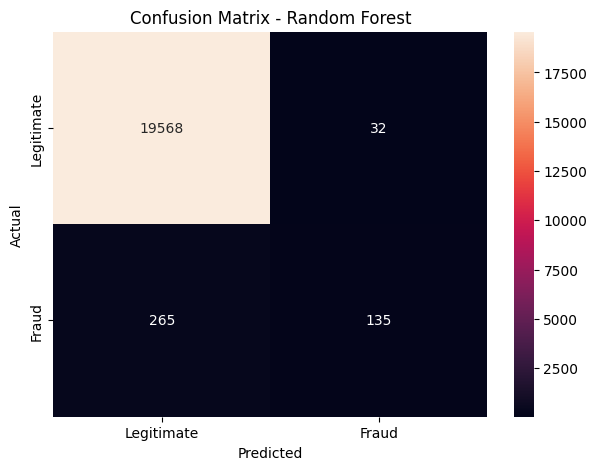

In [71]:
# Confusion Matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [72]:
# Train Extra Trees Classifier

from sklearn.ensemble import ExtraTreesClassifier

extra_trees_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

extra_trees_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Extra Trees model trained successfully!")

Extra Trees model trained successfully!


In [73]:
# Make predictions using Extra Trees

y_pred_et = extra_trees_model.predict(X_test_processed)

print("Extra Trees Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_et,
        target_names=["Legitimate", "Fraud"]
    )
)

Extra Trees Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99     19600
       Fraud       0.84      0.36      0.51       400

    accuracy                           0.99     20000
   macro avg       0.92      0.68      0.75     20000
weighted avg       0.98      0.99      0.98     20000



In [74]:
# Calculate ROC-AUC and PR-AUC for Extra Trees

y_prob_et = extra_trees_model.predict_proba(X_test_processed)[:, 1]

roc_auc_et = roc_auc_score(y_test, y_prob_et)
pr_auc_et = average_precision_score(y_test, y_prob_et)

print(f"ROC-AUC Score: {roc_auc_et:.4f}")
print(f"PR-AUC Score : {pr_auc_et:.4f}")

ROC-AUC Score: 0.8397
PR-AUC Score : 0.5435


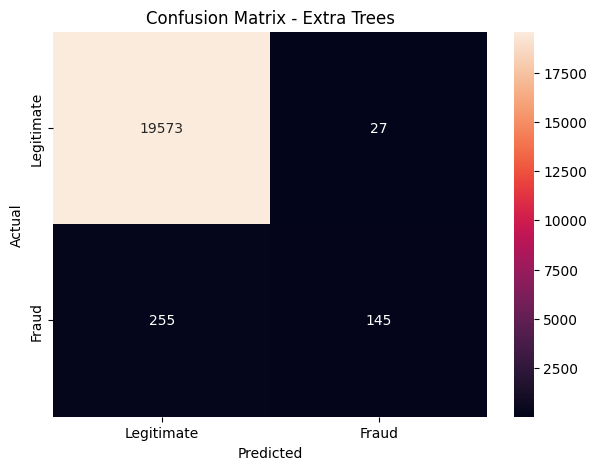

In [75]:
# Confusion Matrix for Extra Trees

cm_et = confusion_matrix(y_test, y_pred_et)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_et,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Extra Trees")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [76]:
# Compare model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees"
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_et
    ],
    "PR-AUC": [
        pr_auc_lr,
        pr_auc_rf,
        pr_auc_et
    ]
})

model_comparison = model_comparison.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,ROC-AUC,PR-AUC
0,Random Forest,0.844903,0.547002
1,Extra Trees,0.839663,0.543536
2,Logistic Regression,0.862549,0.474869


In [77]:
# Analyze different classification thresholds for Random Forest

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1-Score
0,0.1,0.282516,0.6625,0.396114
1,0.2,0.459108,0.6175,0.526652
2,0.3,0.587467,0.5625,0.574713
3,0.4,0.692308,0.4725,0.561664
4,0.5,0.803571,0.3375,0.475352
5,0.6,0.915094,0.2425,0.383399
6,0.7,0.985294,0.1675,0.286325
7,0.8,1.000000,0.1025,0.185941
8,0.9,1.000000,0.0275,0.053528


In [78]:
# Create a validation set for threshold tuning

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training subset:", X_train_sub.shape)
print("Validation set :", X_val.shape)

print("\nTraining subset class distribution:")
print(y_train_sub.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training subset: (72000, 25)
Validation set : (8000, 25)

Training subset class distribution:
is_fraud
0    70560
1     1440
Name: count, dtype: int64

Validation class distribution:
is_fraud
0    7840
1     160
Name: count, dtype: int64


In [79]:
# Prepare training and validation data without data leakage

# Fit preprocessing only on the training subset
preprocessor_val = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_sub_processed = preprocessor_val.fit_transform(X_train_sub)
X_val_processed = preprocessor_val.transform(X_val)

# Apply SMOTE only to the training subset
smote_val = SMOTE(random_state=42)

X_train_sub_balanced, y_train_sub_balanced = smote_val.fit_resample(
    X_train_sub_processed,
    y_train_sub
)

print("Training subset after SMOTE:", X_train_sub_balanced.shape)
print("Validation set:", X_val_processed.shape)

print("\nBalanced training distribution:")
print(y_train_sub_balanced.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

Training subset after SMOTE: (141120, 64)
Validation set: (8000, 64)

Balanced training distribution:
is_fraud
0    70560
1    70560
Name: count, dtype: int64

Validation distribution:
is_fraud
0    7840
1     160
Name: count, dtype: int64


In [81]:
# Train Random Forest on the balanced training subset

random_forest_val = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_val.fit(
    X_train_sub_balanced,
    y_train_sub_balanced
)

print("Random Forest validation model trained successfully!")

Random Forest validation model trained successfully!


In [82]:
# Get fraud probabilities on validation set

y_prob_val = random_forest_val.predict_proba(X_val_processed)[:, 1]

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

validation_threshold_results = []

for threshold in thresholds:
    y_pred_val = (y_prob_val >= threshold).astype(int)

    precision = precision_score(y_val, y_pred_val, zero_division=0)
    recall = recall_score(y_val, y_pred_val, zero_division=0)
    f1 = f1_score(y_val, y_pred_val, zero_division=0)

    validation_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

validation_threshold_results = pd.DataFrame(
    validation_threshold_results
)

validation_threshold_results

,Threshold,Precision,Recall,F1-Score
0,0.1,0.253102,0.63750,0.362345
1,0.2,0.425234,0.56875,0.486631
2,0.3,0.568493,0.51875,0.542484
3,0.4,0.690000,0.43125,0.530769
4,0.5,0.848485,0.35000,0.495575
5,0.6,0.928571,0.24375,0.386139
6,0.7,1.000000,0.16875,0.288770
7,0.8,1.000000,0.10000,0.181818
8,0.9,1.000000,0.01250,0.024691


In [83]:
# Select the best threshold based on validation F1-score

best_threshold = 0.30

print("Selected threshold:", best_threshold)

Selected threshold: 0.3


In [84]:
# Final prediction on untouched test set using selected threshold

y_pred_final = (y_prob_rf >= best_threshold).astype(int)

print("Final Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Legitimate", "Fraud"]
    )
)

Final Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     19600
       Fraud       0.59      0.56      0.57       400

    accuracy                           0.98     20000
   macro avg       0.79      0.78      0.78     20000
weighted avg       0.98      0.98      0.98     20000



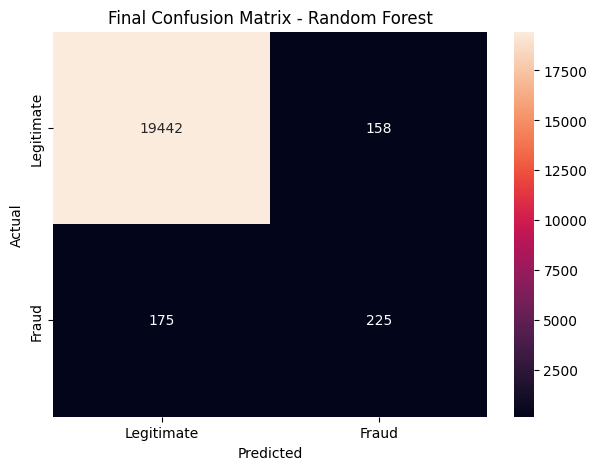

In [85]:
# Final Confusion Matrix

cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Final Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [86]:
# Final model configuration

final_model = random_forest_model
final_threshold = best_threshold

print("Final Model:", type(final_model).__name__)
print("Final Threshold:", final_threshold)

Final Model: RandomForestClassifier
Final Threshold: 0.3


In [87]:
# Save final model and preprocessing pipeline

import joblib

joblib.dump(final_model, "fraud_detection_model.pkl")
joblib.dump(preprocessor, "fraud_detection_preprocessor.pkl")

print("Model saved successfully!")
print("Preprocessor saved successfully!")

Model saved successfully!
Preprocessor saved successfully!
